In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dip-dataset/Drive/new_data/test/mask/14_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/05_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/12_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/17_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/15_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/09_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/04_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/16_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/08_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/18_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/07_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/01_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/10_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/19_test_0.png
/kaggle/input/dip-dataset/Drive/new_data/test/mask/06_test_0.png
/kaggle/input/dip-dataset

In [2]:
import os
print("Available datasets:")
print(os.listdir("../input"))


Available datasets:
['dip-dataset', 'drive-dataset']


In [3]:
dataset_path = "../input/dip-dataset"  # Replace with the folder name
print("Files in the dataset folder:")
print(os.listdir(dataset_path))


Files in the dataset folder:
['Drive']


In [4]:
import os

def get_all_image_paths_recursive(root_folder, extensions=('.png', '.jpg', '.jpeg','.gif','.tif')):
    """
    Recursively retrieves all image file paths from a given folder, including all nested subfolders.

    Args:
        root_folder (str): The path to the root folder.
        extensions (tuple): File extensions to include (default: common image types).

    Returns:
        list: A list of full paths to image files.
    """
    image_paths = []
    for current_folder, subfolders, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(extensions):  # Match valid image extensions
                image_paths.append(os.path.join(current_folder, file))
    return image_paths

# Replace 'your-dataset-folder' with the root folder of your dataset
root_dataset_path = "../input/dip-dataset"  # Update this with the dataset folder name

# Get all image paths
image_paths = get_all_image_paths_recursive(root_dataset_path)

# Print the total number of images and some example paths
print(f"Found {len(image_paths)} images in nested folders.")
for path in image_paths[:10]:  # Print the first 10 image paths
    print(path)


Found 320 images in nested folders.
../input/dip-dataset/Drive/new_data/test/mask/14_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/05_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/12_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/17_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/15_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/09_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/04_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/16_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/08_test_0.png
../input/dip-dataset/Drive/new_data/test/mask/18_test_0.png


In [5]:
import os
print("Absolute path to dataset folder:", os.path.abspath("dip-dataset"))


Absolute path to dataset folder: /kaggle/working/dip-dataset


In [6]:
import os
print("Available datasets:")
print(os.listdir("../input"))

Available datasets:
['dip-dataset', 'drive-dataset']


In [7]:
import os

# List all files in the /kaggle/input/ directory
input_folder = '/kaggle/input/'
print("Contents of Kaggle input folder:", os.listdir(input_folder))


Contents of Kaggle input folder: ['dip-dataset', 'drive-dataset']


Total images found: 80
Processing image: /kaggle/input/dip-dataset/Drive/new_data/train/image/25_training_0.png


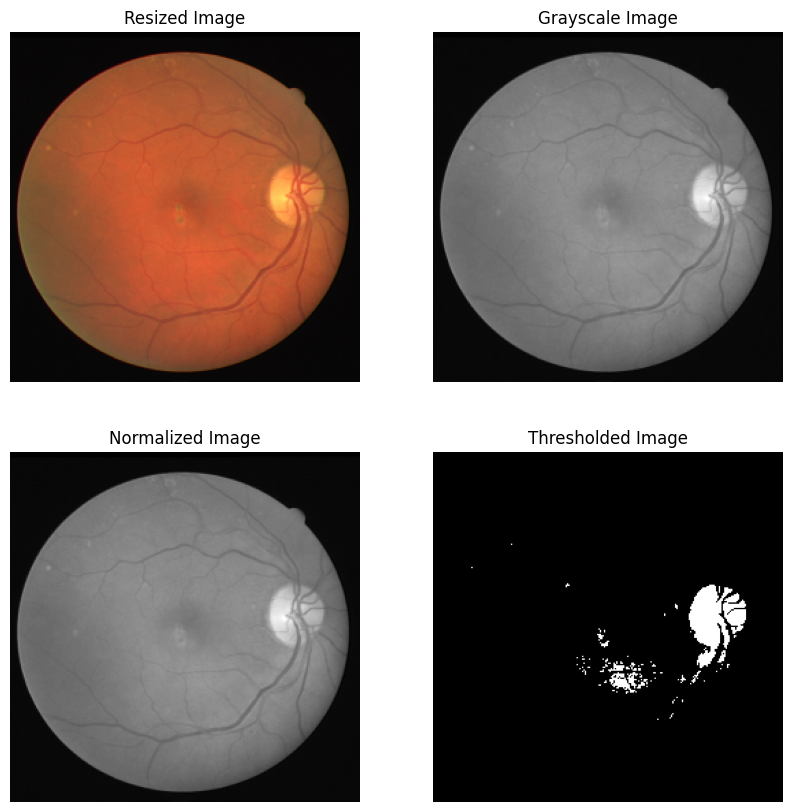

Processing image: /kaggle/input/dip-dataset/Drive/new_data/train/image/37_training_3.png


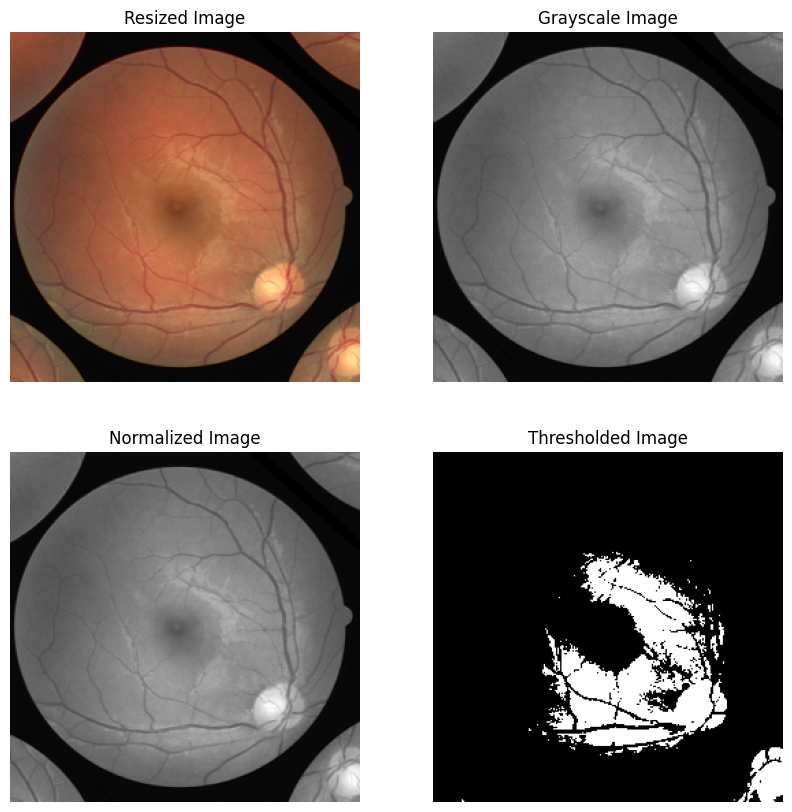

Processing image: /kaggle/input/dip-dataset/Drive/new_data/train/image/37_training_1.png


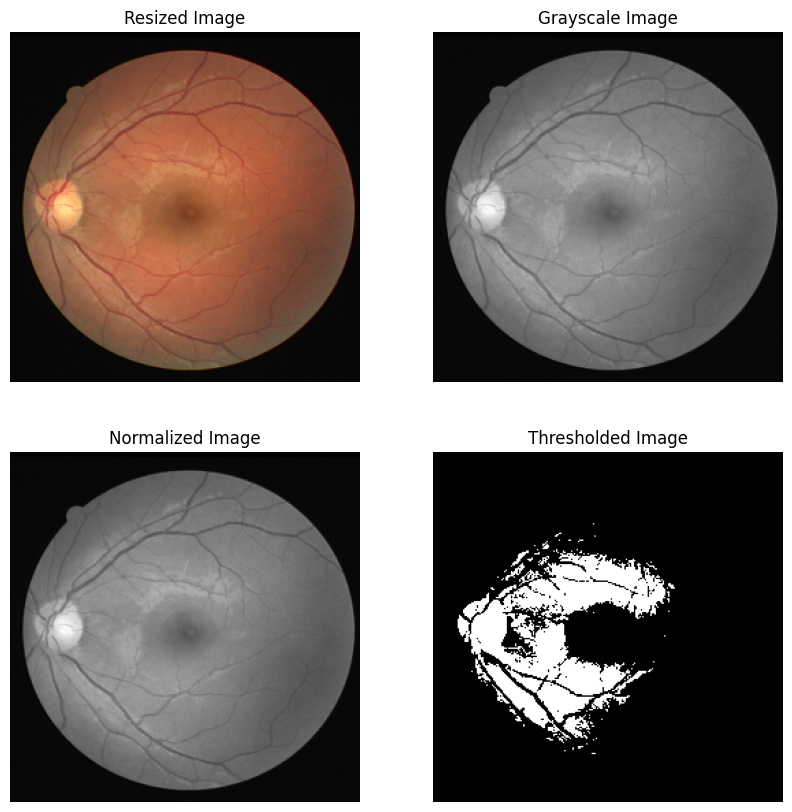

Processing image: /kaggle/input/dip-dataset/Drive/new_data/train/image/36_training_3.png


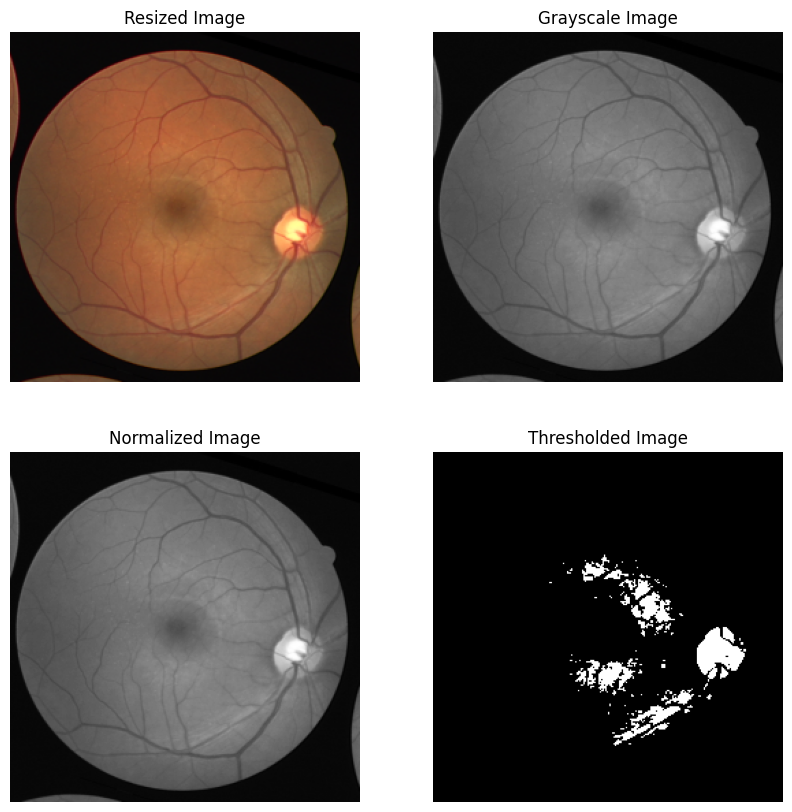

Processing image: /kaggle/input/dip-dataset/Drive/new_data/train/image/22_training_0.png


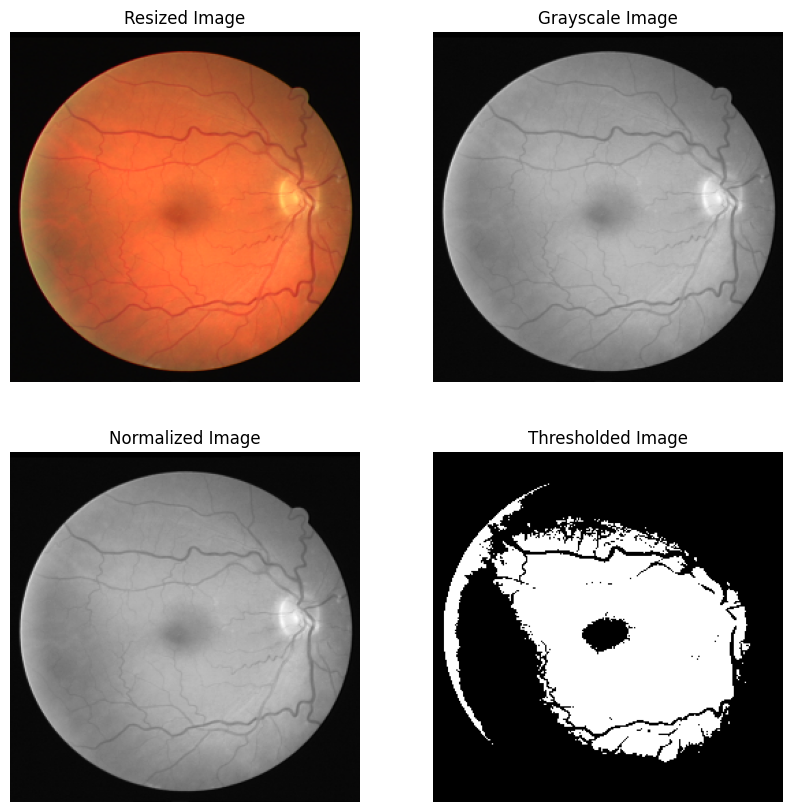

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


dataset_dir = "/kaggle/input/dip-dataset/Drive/new_data/train/image"  

# Function to list all image files in the 'image' folder
def get_all_image_paths(dataset_dir):
    image_paths = []
    for root, dirs, files in os.walk(dataset_dir):
        for file in files:
            if file.lower().endswith(('.png', '.tif')):  
                full_path = os.path.join(root, file)
                image_paths.append(full_path)
    return image_paths

# List all images in the 'image' folder
image_paths = get_all_image_paths(dataset_dir)

# Display the number of images found
print(f"Total images found: {len(image_paths)}")

# Preprocessing function 
def preprocess_image(image_path):
    # Read the image (handles .png and .tiff formats)
    image = cv2.imread(image_path)

    # Check if image was loaded
    if image is None:
        print(f"Error loading image: {image_path}")
        return None
    
    # Resize the image
    resized_image = cv2.resize(image, (256, 256))
    
    # Convert to grayscale
    gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
    
    # Normalize the image (scale pixel values between 0 and 1)
    normalized_image = gray_image / 255.0
    
    # Thresholding (apply binary thresholding as an example)
    _, thresh_image = cv2.threshold(normalized_image, 0.5, 1.0, cv2.THRESH_BINARY)
    
    return resized_image, gray_image, normalized_image, thresh_image

# Loop through images, apply preprocessing, and display results
for image_path in image_paths[:5]:  # Limiting to the first 5 images for display
    print(f"Processing image: {image_path}")
    resized, gray, normalized, thresh = preprocess_image(image_path)
    
    if resized is not None:
        # Display images after preprocessing
        plt.figure(figsize=(10, 10))

        # Original Image
        plt.subplot(2, 2, 1)
        plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
        plt.title("Resized Image")
        plt.axis("off")

        # Grayscale Image
        plt.subplot(2, 2, 2)
        plt.imshow(gray, cmap='gray')
        plt.title("Grayscale Image")
        plt.axis("off")

        # Normalized Image
        plt.subplot(2, 2, 3)
        plt.imshow(normalized, cmap='gray')
        plt.title("Normalized Image")
        plt.axis("off")

        # Thresholded Image
        plt.subplot(2, 2, 4)
        plt.imshow(thresh, cmap='gray')
        plt.title("Thresholded Image")
        plt.axis("off")

        plt.show()



Total normal images found: 80
Total mask images found: 80


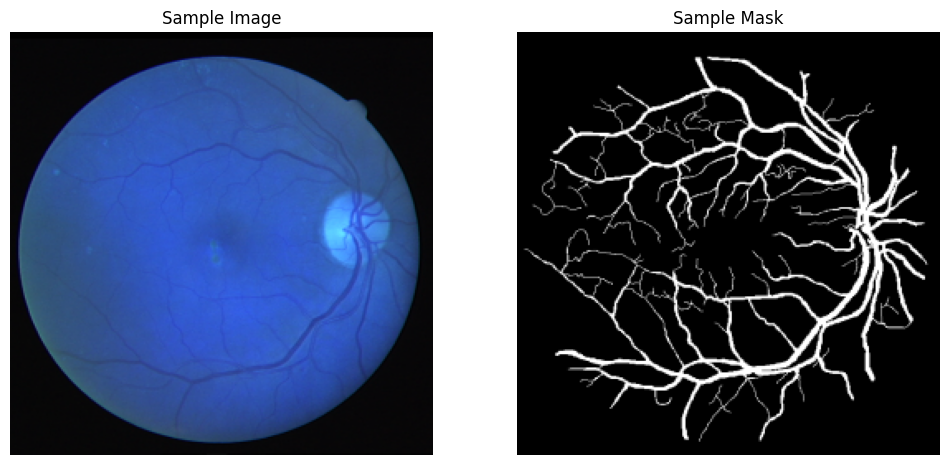

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the paths
image_dir = '/kaggle/input/dip-dataset/Drive/new_data/train/image/'
mask_dir = '/kaggle/input/dip-dataset/Drive/new_data/train/mask/'

# Get all image paths and mask paths
def get_all_image_paths(dir_path):
    paths = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.endswith(('.png', '.tif')):  
                paths.append(os.path.join(root, file))
    return paths

def get_all_mask_paths(dir_path):
    paths = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.endswith('.png'):  
                paths.append(os.path.join(root, file))
    return paths

# Fetch the paths for images and masks
image_paths = get_all_image_paths(image_dir)
mask_paths = get_all_mask_paths(mask_dir)

print(f"Total normal images found: {len(image_paths)}")
print(f"Total mask images found: {len(mask_paths)}")

# Resize and normalize images and masks
def load_images_and_masks(image_paths, mask_paths, target_size=(256, 256)):
    images = []
    masks = []
    
    for img_path, mask_path in zip(image_paths, mask_paths):
        # Read and preprocess the image
        img = cv2.imread(img_path)
        img = cv2.resize(img, target_size)
        img = img / 255.0  # Normalize image
        
        # Read and preprocess the mask (Assuming binary mask)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, target_size)
        mask = mask / 255.0  # Normalize mask (0 or 1)
        
        images.append(img)
        masks.append(mask)
    
    images = np.array(images)
    masks = np.array(masks)
    return images, masks

# Load images and masks
images, masks = load_images_and_masks(image_paths, mask_paths)

# Show a sample image and mask
plt.figure(figsize=(12, 6))

# Display the first image
plt.subplot(1, 2, 1)
plt.imshow(images[0])
plt.title('Sample Image')
plt.axis('off')

# Display the corresponding mask
plt.subplot(1, 2, 2)
plt.imshow(masks[0], cmap='gray')
plt.title('Sample Mask')
plt.axis('off')

plt.show()


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)
    
    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    c4 = BatchNormalization()(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Dropout(0.5)(c5)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model

def build_modified_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Dropout(0.5)(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Dropout(0.5)(c5)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Dropout(0.5)(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

# Load models
unet_model = build_unet(input_shape=(256, 256, 3))
modified_unet_model = build_modified_unet(input_shape=(256, 256, 3))

# Compile models
unet_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
modified_unet_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train models
history_unet = unet_model.fit(images, masks, epochs=10, batch_size=8, validation_split=0.2, callbacks=[early_stopping])
history_modified_unet = modified_unet_model.fit(images, masks, epochs=10, batch_size=8, validation_split=0.2, callbacks=[early_stopping])


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 258s 31s/step - accuracy: 0.6927 - loss: 0.6166 - val_accuracy: 0.8357 - val_loss: 0.5738
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 244s 31s/step - accuracy: 0.8419 - loss: 0.2317 - val_accuracy: 0.8357 - val_loss: 0.3744
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 248s 31s/step - accuracy: 0.8427 - loss: 0.2056 - val_accuracy: 0.8357 - val_loss: 0.3981
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 243s 31s/step - accuracy: 0.8535 - loss: 0.1751 - val_accuracy: 0.8159 - val_loss: 0.3924
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 246s 31s/step - accuracy: 0.8608 - loss: 0.1505 - val_accuracy: 0.8296 - val_loss: 0.3648
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 261s 31s/step - accuracy: 0.8636 - loss: 0.1410 - val_accuracy: 0.8357 - val_loss: 0.3166
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 241s 30s/step - accuracy: 0.8647 - loss: 0.1371 - val_accuracy: 0.8357 - val_loss: 0.3156
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 245s 31s/step - accuracy: 0.8646 - loss: 0.1312 - val_accuracy: 0.8357 - val_loss:

In [13]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
train_images, test_images, train_masks, test_masks = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

# Print the shapes of the training and testing data
print(f"Train images shape: {train_images.shape}")
print(f"Train masks shape: {train_masks.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test masks shape: {test_masks.shape}")


Train images shape: (64, 256, 256, 3)
Train masks shape: (64, 256, 256)
Test images shape: (16, 256, 256, 3)
Test masks shape: (16, 256, 256)


In [25]:
import numpy as np
from sklearn.metrics import jaccard_score, accuracy_score, precision_score, recall_score

def dice_score(y_true, y_pred):
    """
    Calculate the Dice Coefficient.
    """
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred)
    return (2. * intersection) / union if union != 0 else 1.0

def evaluate_model(model, test_images, test_masks):
    # Step 1: Predict on test images
    print("Predicting on test images...")
    predictions = model.predict(test_images)
    
    # Step 2: Check prediction range
    print(f"Predictions range: min={predictions.min()}, max={predictions.max()}")

    # Step 3: Threshold predictions (binary conversion)
    threshold = 0.5
    y_pred_binary = (predictions >= threshold).astype(np.uint8)
    print(f"Unique values in y_pred_binary: {np.unique(y_pred_binary)}")
    
    # Step 4: Ensure test_masks are binary (0 or 1)
    test_masks_binary = (test_masks > 0).astype(np.uint8)
    print(f"Unique values in test_masks_binary: {np.unique(test_masks_binary)}")
    
    # Step 5: Flatten arrays for metric calculation
    y_true_flat = test_masks_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    print(f"Flattened y_true shape: {y_true_flat.shape}, Flattened y_pred shape: {y_pred_flat.shape}")

    # Debug: Check consistency in shapes
    if y_true_flat.shape != y_pred_flat.shape:
        raise ValueError("Mismatch between y_true and y_pred shapes!")
    
    # Step 6: Calculate metrics
    dice = dice_score(y_true_flat, y_pred_flat)
    jaccard = jaccard_score(y_true_flat, y_pred_flat, average='binary')
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    precision = precision_score(y_true_flat, y_pred_flat, average='binary', zero_division=1)
    recall = recall_score(y_true_flat, y_pred_flat, average='binary', zero_division=1)

    # Step 7: Return results
    return {
        "Dice Coefficient": dice,
        "Jaccard Index": jaccard,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
    }


In [ ]:
from tensorflow.keras import layers, models

def unet_model(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)
    
    # Contracting path (Encoder)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    # Expanding path (Decoder)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    u2 = layers.UpSampling2D((2, 2))(c2)
    c2_up = layers.concatenate([u2, c1], axis=3)
    
    # Output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c2_up)
    
    model = models.Model(inputs, outputs)
    return model


In [ ]:
def modified_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)
    
    # Modified Contracting path with more layers
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    # Expanding path
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    u2 = layers.UpSampling2D((2, 2))(c2)
    c2_up = layers.concatenate([u2, c1], axis=3)
    
    # Output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c2_up)
    
    model = models.Model(inputs, outputs)
    return model


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model

def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model


In [ ]:
from tensorflow.keras.layers import Dropout

def build_modified_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Dropout(0.5)(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Dropout(0.5)(c5)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Dropout(0.5)(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model


In [ ]:
from tensorflow.keras.optimizers import Adam

# Load models
unet_model = build_unet(input_shape=(256, 256, 3))
modified_unet_model = build_modified_unet(input_shape=(256, 256, 3))

# Compile models
unet_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
modified_unet_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train models
history_unet = unet_model.fit(images, masks, epochs=10, batch_size=8, validation_split=0.2)
history_modified_unet = modified_unet_model.fit(images, masks, epochs=10, batch_size=8, validation_split=0.2)


In [ ]:
import numpy as np
from sklearn.metrics import jaccard_score, accuracy_score, precision_score, recall_score

def evaluate_model(model, test_images, test_masks):
    # Predict on test images
    print("Predicting on test images...")
    predictions = model.predict(test_images)
    
    # Debug: Print predictions shape and value range
    print(f"Predictions shape: {predictions.shape}, dtype: {predictions.dtype}")
    print(f"Prediction value range: min={predictions.min()}, max={predictions.max()}")
    
    # Threshold predictions to binary (0 or 1)
    threshold = 0.5
    y_pred_binary = (predictions > threshold).astype(np.uint8)
    
    # Debug: Check unique values in y_pred_binary
    print(f"Unique values in y_pred_binary after thresholding: {np.unique(y_pred_binary)}")
    
    # Ensure test_masks are binary (0 or 1)
    test_masks_binary = (test_masks > 0).astype(np.uint8)
    
    # Debug: Check unique values in test_masks_binary
    print(f"Unique values in test_masks_binary: {np.unique(test_masks_binary)}")
    
    # Flatten the arrays for metric calculation
    y_true_flat = test_masks_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    
    # Debug: Ensure y_true_flat and y_pred_flat are binary and have the same shape
    print(f"Flattened y_true_flat shape: {y_true_flat.shape}, unique values: {np.unique(y_true_flat)}")
    print(f"Flattened y_pred_flat shape: {y_pred_flat.shape}, unique values: {np.unique(y_pred_flat)}")
    
    # Calculate metrics
    dice = dice_score(y_true_flat, y_pred_flat)
    jaccard = jaccard_score(y_true_flat, y_pred_flat, average='binary')
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    precision = precision_score(y_true_flat, y_pred_flat, average='binary', zero_division=1)
    recall = recall_score(y_true_flat, y_pred_flat, average='binary', zero_division=1)
    
    # Return metrics
    return {
        "Dice Coefficient": dice,
        "Jaccard Index": jaccard,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
    }

# Evaluate the model
metrics_unet = evaluate_model(unet_model, test_images, test_masks)

# Print the results
print("Evaluation Results:")
for metric, value in metrics_unet.items():
    print(f"{metric}: {value}")


In [ ]:
def plot_training_curves(history, title="Training and Validation Loss"):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

# Example for UNet
plot_training_curves(history_unet, title="UNet Training and Validation Loss")

# Example for Modified UNet
plot_training_curves(history_modified_unet, title="Modified UNet Training and Validation Loss")


In [ ]:
def plot_metric_curve(history, metric, title="Metric Over Epochs"):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history[metric], label=f'Training {metric.capitalize()}', color='blue')
    plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric.capitalize()}', color='orange')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid()
    plt.show()

# Example for UNet
plot_metric_curve(history_unet, metric="accuracy", title="UNet Accuracy Over Epochs")

# Example for Modified UNet
plot_metric_curve(history_modified_unet, metric="accuracy", title="Modified UNet Accuracy Over Epochs")


In [ ]:
# Assuming `predictions` are the outputs from the model
predictions = unet_model.predict(test_images)

# Apply threshold to create binary predictions
threshold = 0.5
y_pred_binary = (predictions > threshold).astype(np.uint8)

print("Shape of predictions:", predictions.shape)
print("Shape of y_pred_binary:", y_pred_binary.shape)


In [ ]:
y_true_flat = test_masks.flatten()  # Flatten ground truth masks
y_pred_flat = y_pred_binary.flatten()  # Flatten binary predictions


In [ ]:
print("Unique values in y_true_flat:", np.unique(y_true_flat))
print("Unique values in y_pred_flat:", np.unique(y_pred_flat))


In [ ]:
# Step 1: Get predictions from the model
predictions = unet_model.predict(test_images)

# Step 2: Binarize the predictions
threshold = 0.5
y_pred_binary = (predictions > threshold).astype(np.uint8)

# Step 3: Verify consistency
assert test_masks.shape == y_pred_binary.shape, "Shape mismatch between ground truth and predictions!"

# Step 4: Flatten the arrays
y_true_flat = test_masks.flatten()
y_pred_flat = y_pred_binary.flatten()

# Step 5: Debug unique values
print("Unique values in y_true_flat:", np.unique(y_true_flat))
print("Unique values in y_pred_flat:", np.unique(y_pred_flat))

# Step 6: Calculate metrics
dice = dice_score(y_true_flat, y_pred_flat)
print("Dice Score:", dice)
